In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [2]:
class AgentState(TypedDict):
    name: str
    guesses: List[int]
    attempts: int
    lowerbound: int
    upperbound: int
    hint: str
    target_number: int

In [3]:
def setup_node(state:AgentState) -> AgentState:
    """Sets up the initial state of the game."""
    state['name'] = f"Welcome {state['name']}"
    state['guesses'] = []
    state['attempts'] = 0
    state['lowerbound'] = 1
    state['upperbound'] = 20
    state['target_number']= random.randint(1,20)
    print(f"{state['name']} the game has begun.")

    return state

In [4]:
def guess_node(state:AgentState) -> AgentState:
    """Handles the guessing logic of the game."""
    possible_guesses = [i for i in range(state['lowerbound'], state['upperbound']+ 1) if i not in state['guesses']]

    if possible_guesses:
        guess = random.choice(possible_guesses)
    else:
        guess = random.randint(state['lowerbound'], state['upperbound'])

    state['guesses'].append(guess)
    state['attempts'] += 1

    print(f"Attempt {state['attempts']}: Guessing {guess} (Current range: {state['lowerbound']}-{state['upperbound']})")
    return state

In [5]:
def hint_node(state:AgentState) ->AgentState:
    """Provides a hint based on the last guess."""
    latest_guess = state['guesses'][-1]
    target_number = state['target_number']

    if latest_guess < target_number:
        state['hint'] = f"The number is higher than {latest_guess}."

        state['lowerbound'] = max(state['lowerbound'], latest_guess + 1)
        print(f'Hint: {state["hint"]}')
    elif latest_guess > target_number:
        state['hint'] = f"The number is lower than {latest_guess}."

        state['upperbound'] = min(state['upperbound'], latest_guess - 1)
        print(f'Hint: {state["hint"]}')
    else:
        state['hint'] = f"Congratulations! You've guessed the number {target_number} in {state['attempts']} attempts."
        print(state['hint'])

    return state

In [6]:
def should_continue(state:AgentState) -> AgentState:
    """determines whether the game should continue based on the last guess."""
    if state['attempts'] < 7:
        print("Entering loop", state['attempts'])
        return "continue"
    else:
        return "exit"

In [7]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint", hint_node)

graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")

graph.add_conditional_edges(
    "hint",
    should_continue,
    {
        "continue": "guess",
        "exit": END
    }
)

graph.set_entry_point("setup")

app = graph.compile()

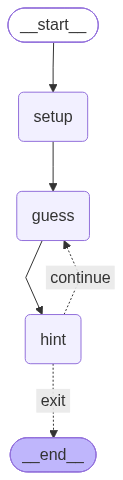

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
app.invoke({"name": "Krrish", "guesses": [], "attempts": 0, "lowerbound": 1, "upperbound": 20, "hint": "", "target_number": 0})

Welcome Krrish the game has begun.
Attempt 1: Guessing 16 (Current range: 1-20)
Hint: The number is lower than 16.
Entering loop 1
Attempt 2: Guessing 2 (Current range: 1-15)
Hint: The number is higher than 2.
Entering loop 2
Attempt 3: Guessing 6 (Current range: 3-15)
Hint: The number is higher than 6.
Entering loop 3
Attempt 4: Guessing 14 (Current range: 7-15)
Hint: The number is lower than 14.
Entering loop 4
Attempt 5: Guessing 9 (Current range: 7-13)
Hint: The number is higher than 9.
Entering loop 5
Attempt 6: Guessing 11 (Current range: 10-13)
Hint: The number is lower than 11.
Entering loop 6
Attempt 7: Guessing 10 (Current range: 10-10)
Congratulations! You've guessed the number 10 in 7 attempts.


{'name': 'Welcome Krrish',
 'guesses': [16, 2, 6, 14, 9, 11, 10],
 'attempts': 7,
 'lowerbound': 10,
 'upperbound': 10,
 'hint': "Congratulations! You've guessed the number 10 in 7 attempts.",
 'target_number': 10}